In [1]:
import pandas as pd

df = pd.read_csv("DataSalaries.csv")

In [2]:
df.head()

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,...,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,...,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,...,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,100,9.7,Masters,...,2.0,BRL,29531,0.102,9.3,5.6,5,False,7.8,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,0,3.2,Bachelors,...,4.0,USD,70105,0.064,10.6,4.6,4,False,9.1,5.1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_title                   5000 non-null   str    
 1   experience_level            5000 non-null   str    
 2   employment_type             5000 non-null   str    
 3   company_size                5000 non-null   str    
 4   company_location            5000 non-null   str    
 5   employee_residence          5000 non-null   str    
 6   industry                    5000 non-null   str    
 7   remote_ratio                5000 non-null   int64  
 8   years_experience            5000 non-null   float64
 9   education_level             5000 non-null   str    
 10  primary_language            5000 non-null   str    
 11  has_ml_in_title             5000 non-null   bool   
 12  manages_people              5000 non-null   bool   
 13  team_size                   5000 non-null   

In [4]:
df.describe()

,remote_ratio,years_experience,team_size,certifications_count,weekly_hours,ai_tools_hours_per_week,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,upskilling_hours_per_month,fears_ai_automation_score
count,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.08000,8.361440,7.93620,1.820400,44.345400,8.437400,98605.406200,0.139020,10.802720,6.685320,5.230800,8.680740,4.846080
std,41.45428,4.820808,2.64793,1.344212,6.142761,5.503637,55369.310473,0.184243,5.152959,1.364302,2.412695,4.422549,1.725924
min,0.00000,0.000000,1.00000,0.000000,24.400000,0.000000,12000.000000,0.000000,0.000000,1.100000,1.000000,0.000000,1.000000
25%,0.00000,4.800000,6.00000,1.000000,40.100000,3.300000,55592.750000,0.017000,7.100000,5.800000,3.000000,5.600000,3.700000
50%,50.00000,8.100000,8.00000,2.000000,44.400000,8.500000,90572.000000,0.072000,10.600000,6.700000,5.000000,8.700000,4.800000
75%,100.00000,11.500000,10.00000,3.000000,48.500000,12.625000,129657.750000,0.175000,14.200000,7.600000,7.000000,11.700000,6.000000
max,100.00000,23.700000,19.00000,8.000000,67.300000,25.200000,372347.000000,1.264000,30.800000,10.000000,16.000000,26.200000,10.000000


In [5]:
selected_df = df[
    ["salary_usd", "job_title", "years_experience"]
]
salary_by_job = (
    df.groupby("job_title")
      .agg(
          number_of_jobs=("salary_usd", "count"),
          average_salary=("salary_usd", "mean"),
          median_salary=("salary_usd", "median"),
          highest_salary=("salary_usd", "max")
      )
      .sort_values("median_salary", ascending=False)
      .reset_index()
)

salary_by_job[
    ["average_salary", "median_salary", "highest_salary"]
] = salary_by_job[
    ["average_salary", "median_salary", "highest_salary"]
].round(2)

salary_by_job

,job_title,number_of_jobs,average_salary,median_salary,highest_salary
0,LLM Engineer,242,110920.23,107354.0,283641
1,Research Scientist,269,109608.48,105886.0,303435
2,Machine Learning Engineer,593,110434.21,105327.0,352584
3,Data Science Manager,238,114440.70,103948.5,372347
4,Computer Vision Engineer,218,108249.98,103856.0,285305
5,AI Engineer,506,110903.48,101191.5,340887
6,Data Engineer,682,100878.35,91588.0,361230
7,MLOps Engineer,306,98587.72,89506.0,300823
8,Data Scientist,709,94938.99,89478.0,320354
9,Analytics Engineer,317,90432.25,85632.0,273649


In [6]:
experience_order = [
    "Entry",
    "Mid",
    "Senior",
    "Lead",
    "Executive"
]

df["experience_level"] = pd.Categorical(
    df["experience_level"],
    categories=experience_order,
    ordered=True
)

salary_by_job_experience = (
    df.groupby(
        ["job_title", "experience_level"],
        observed=True
    )
    .agg(
        number_of_jobs=("salary_usd", "count"),
        average_salary=("salary_usd", "mean"),
        median_salary=("salary_usd", "median")
    )
    .reset_index()
)

salary_by_job_experience[
    ["average_salary", "median_salary"]
] = salary_by_job_experience[
    ["average_salary", "median_salary"]
].round(2)

salary_by_job_experience

,job_title,experience_level,number_of_jobs,average_salary,median_salary
0,AI Engineer,Entry,107,72145.71,71776.0
1,AI Engineer,Mid,172,92936.08,93863.5
2,AI Engineer,Senior,131,124406.69,119421.0
3,AI Engineer,Lead,66,156953.82,151176.0
4,AI Engineer,Executive,30,191877.83,206967.0
5,Analytics Engineer,Entry,61,56786.66,57875.0
6,Analytics Engineer,Mid,103,84384.15,85668.0
7,Analytics Engineer,Senior,96,96390.78,95284.0
8,Analytics Engineer,Lead,40,114726.85,113292.0
9,Analytics Engineer,Executive,17,156993.00,181041.0


In [7]:
experience_order = [
    "Entry",
    "Mid",
    "Senior",
    "Lead",
    "Executive"
]

job_order = salary_by_job["job_title"].tolist()

salary_pivot = (
    df.pivot_table(
        index="job_title",
        columns="experience_level",
        values="salary_usd",
        aggfunc="median",
        observed=True
    )
    .reindex(
        index=job_order,
        columns=experience_order
    )
    .rename_axis(
        index=None,
        columns=None
    )
)

salary_pivot

,Entry,Mid,Senior,Lead,Executive
LLM Engineer,81994.0,108383.0,134869.5,143807.0,179297.5
Research Scientist,72337.0,104878.0,116269.0,146254.0,184320.0
Machine Learning Engineer,65886.5,96177.0,127308.5,147338.0,173856.0
Data Science Manager,58758.0,98347.0,122715.0,186766.0,195824.0
Computer Vision Engineer,67945.0,89723.5,125707.5,145128.0,203383.0
AI Engineer,71776.0,93863.5,119421.0,151176.0,206967.0
Data Engineer,63995.0,86029.0,116623.0,139305.0,158750.0
MLOps Engineer,66514.5,89577.5,103845.0,154441.0,201867.0
Data Scientist,56999.5,86438.0,104993.0,125983.0,154355.0
Analytics Engineer,57875.0,85668.0,95284.0,113292.0,181041.0


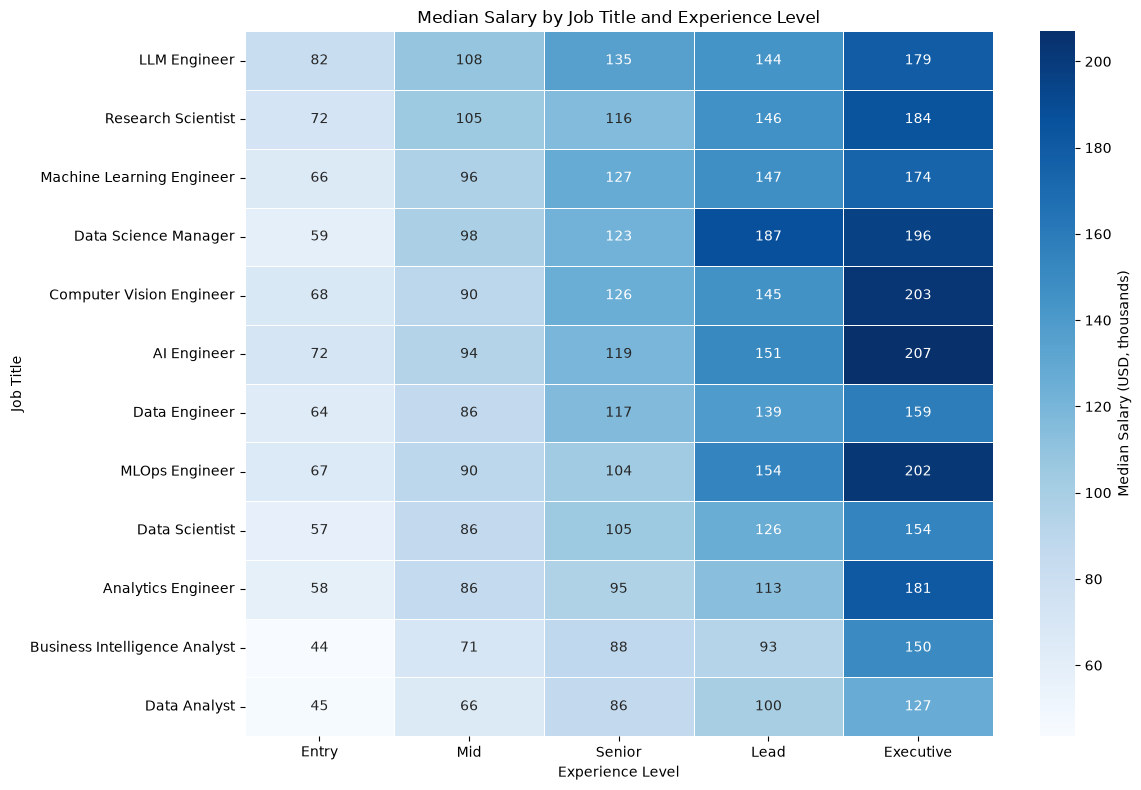

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

# Use "../images" if your notebook is inside a notebooks folder.
image_folder = Path("../images")
image_folder.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    salary_pivot / 1000,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Median Salary (USD, thousands)"}
)

plt.title("Median Salary by Job Title and Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Job Title")
plt.tight_layout()

plt.savefig(
    image_folder / "salary_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

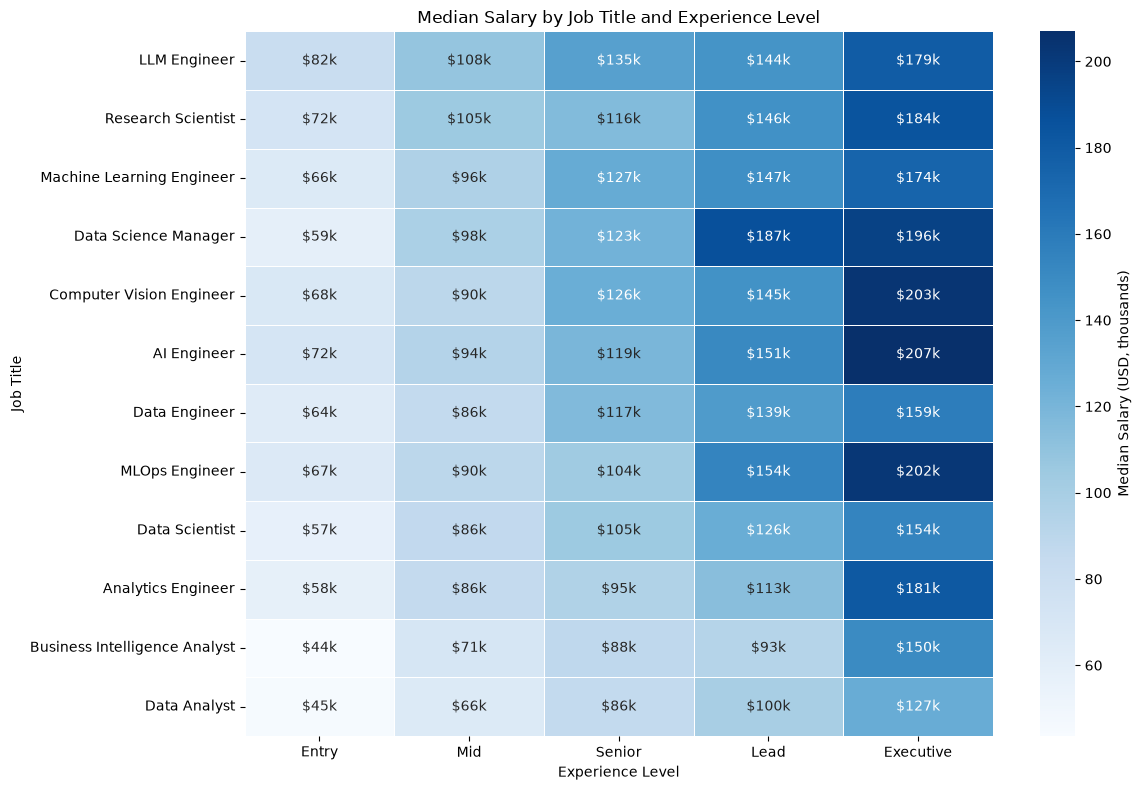

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

image_folder = Path("../images")
image_folder.mkdir(parents=True, exist_ok=True)

annotations = salary_pivot.map(
    lambda salary: f"${salary / 1000:.0f}k"
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    salary_pivot / 1000,
    annot=annotations,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Median Salary (USD, thousands)"}
)

plt.title("Median Salary by Job Title and Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Job Title")
plt.tight_layout()

plt.savefig(
    image_folder / "salary_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.show()

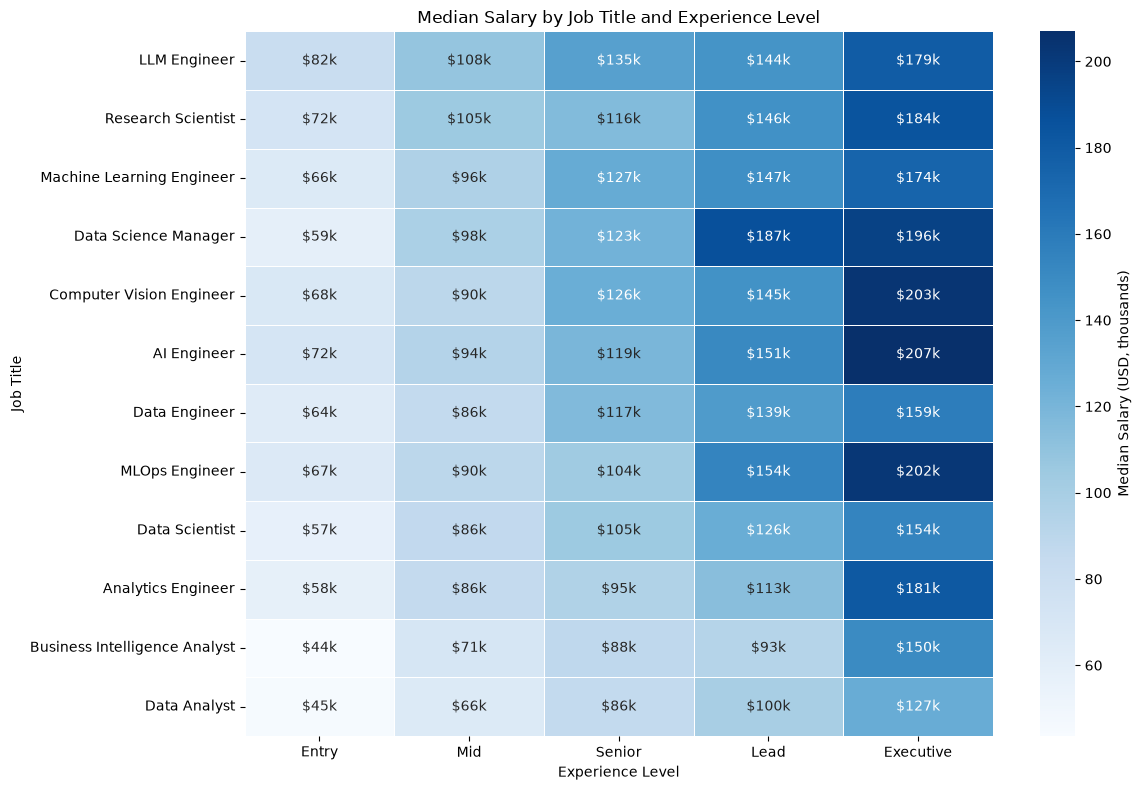

Saved to: /Users/draekon/Desktop/data_project/images/salary_heatmap.png
Image exists: True


In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

# Create data_project/images/
image_folder = Path("images")
image_folder.mkdir(parents=True, exist_ok=True)

annotations = salary_pivot.map(
    lambda salary: f"${salary / 1000:.0f}k"
)

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    salary_pivot / 1000,
    annot=annotations,
    fmt="",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Median Salary (USD, thousands)"},
    ax=ax
)

ax.set_title("Median Salary by Job Title and Experience Level")
ax.set_xlabel("Experience Level")
ax.set_ylabel("Job Title")

fig.tight_layout()

image_path = image_folder / "salary_heatmap.png"

fig.savefig(
    image_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:", image_path.resolve())
print("Image exists:", image_path.exists())

In [11]:
from pathlib import Path

image_path = Path("images/salary_heatmap.png")

print("Current folder:", Path.cwd())
print("Image path:", image_path.resolve())
print("Image exists:", image_path.exists())

if image_path.exists():
    print("File size:", image_path.stat().st_size, "bytes")

Current folder: /Users/draekon/Desktop/data_project
Image path: /Users/draekon/Desktop/data_project/images/salary_heatmap.png
Image exists: True
File size: 391550 bytes


In [12]:
sample_sizes = df.pivot_table(
    index="job_title",
    columns="experience_level",
    values="salary_usd",
    aggfunc="count",
    observed=True
)

sample_sizes

experience_level,Entry,Mid,Senior,Lead,Executive
job_title,,,,,
AI Engineer,107,172,131,66,30
Analytics Engineer,61,103,96,40,17
Business Intelligence Analyst,58,92,97,32,14
Computer Vision Engineer,45,68,64,27,14
Data Analyst,122,216,190,65,34
Data Engineer,121,215,215,101,30
Data Science Manager,42,83,73,28,12
Data Scientist,138,203,233,110,25
LLM Engineer,65,73,74,26,4


In [13]:
salary_by_location = (
    df.groupby("company_location")
      .agg(
          number_of_jobs=("salary_usd", "count"),
          median_salary=("salary_usd", "median"),
          average_salary=("salary_usd", "mean")
      )
      .sort_values("median_salary", ascending=False)
      .reset_index()
)

salary_by_location

,company_location,number_of_jobs,median_salary,average_salary
0,US,1786,126987.0,135662.267637
1,CA,350,101215.5,107260.702857
2,AU,240,100133.0,108565.245833
3,GB,488,95321.0,100562.028689
4,NL,200,94470.0,102304.445000
5,DE,350,89107.0,96418.974286
6,SG,130,88195.0,94549.830769
7,FR,189,78405.0,85178.455026
8,ES,128,71346.5,73861.109375
9,PL,147,56120.0,58488.816327


In [14]:
salary_by_industry = (
    df.groupby("industry")
      .agg(
          number_of_jobs=("salary_usd", "count"),
          median_salary=("salary_usd", "median"),
          average_salary=("salary_usd", "mean")
      )
      .sort_values("median_salary", ascending=False)
      .reset_index()
)

salary_by_industry

,industry,number_of_jobs,median_salary,average_salary
0,Finance,839,104900.0,111841.929678
1,Technology,1528,96978.5,105201.371073
2,Energy,176,91222.0,99753.693182
3,Consulting,442,90043.5,97220.504525
4,Healthcare,543,86633.0,94223.167587
5,Retail,452,85215.5,92444.555310
6,Manufacturing,302,85136.5,90969.089404
7,Government,254,79114.0,82136.283465
8,Media,268,70329.0,82747.145522
9,Education,196,67627.0,73756.168367


In [15]:
location_experience_pivot = df.pivot_table(
    index="company_location",
    columns="experience_level",
    values="salary_usd",
    aggfunc="median",
    observed=True
)

location_experience_pivot

experience_level,Entry,Mid,Senior,Lead,Executive
company_location,,,,,
AU,70117.0,93722.0,114802.0,144800.5,149578.5
BR,24960.0,35134.0,41978.0,53265.0,57817.0
CA,63503.0,88301.5,114253.5,142640.0,162067.5
DE,61846.5,83006.0,106918.0,143496.5,167683.0
ES,41946.0,56009.5,81326.0,92707.0,122647.0
FR,49685.0,74901.0,94290.0,125755.0,127109.0
GB,62236.5,85082.0,107195.0,128652.0,156505.0
IN,23402.5,31139.0,40763.0,49010.0,55486.0
NL,66473.0,89973.5,104742.0,126934.0,179294.0


In [16]:
location_experience_counts = df.pivot_table(
    index="company_location",
    columns="experience_level",
    values="salary_usd",
    aggfunc="count",
    observed=True
)

location_experience_counts

experience_level,Entry,Mid,Senior,Lead,Executive
company_location,,,,,
AU,42,83,71,32,12
BR,58,57,58,27,10
CA,63,114,108,41,24
DE,72,125,100,42,11
ES,23,34,43,21,7
FR,43,60,58,23,5
GB,88,160,143,73,24
IN,158,251,239,103,31
NL,35,58,59,37,11


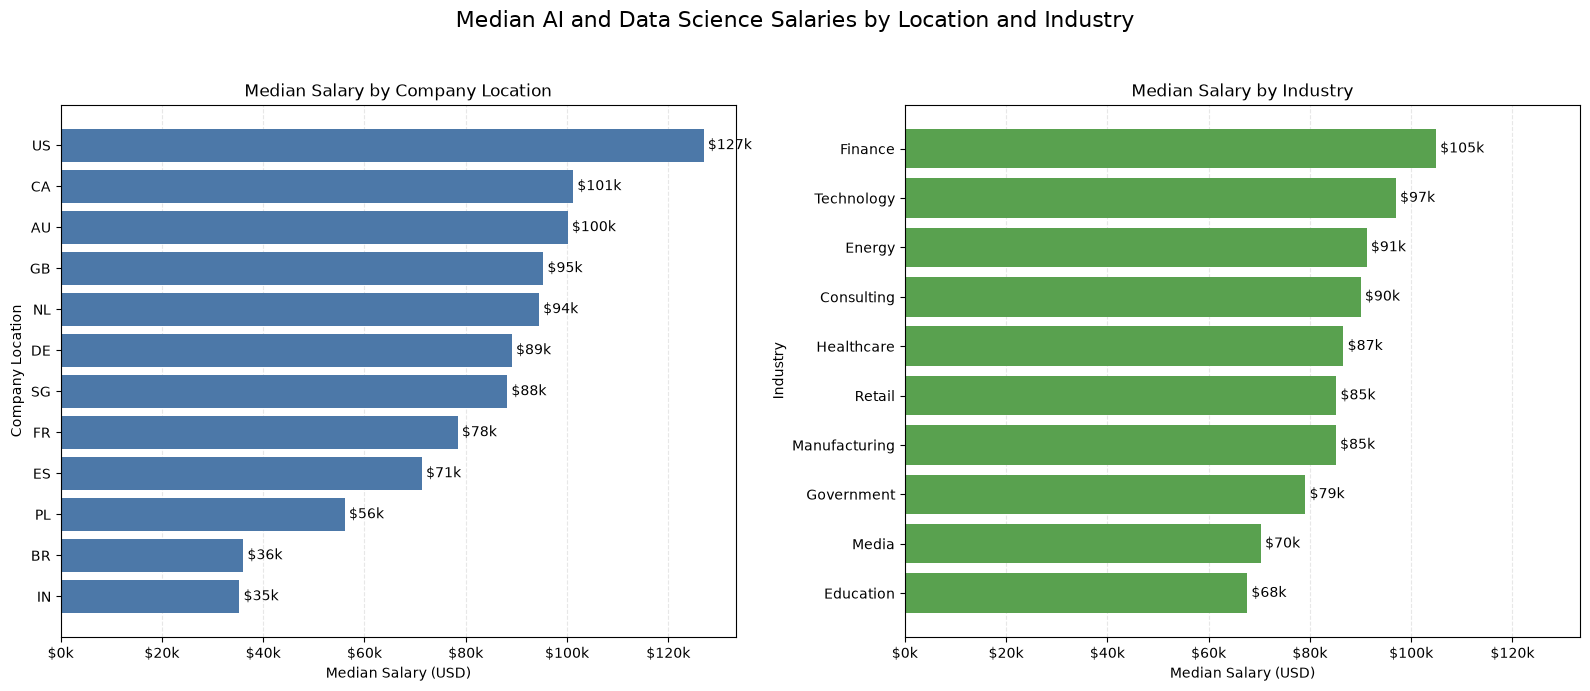

In [17]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

location_plot = salary_by_location.sort_values(
    "median_salary",
    ascending=True
)

industry_plot = salary_by_industry.sort_values(
    "median_salary",
    ascending=True
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 7),
    sharex=True
)

# Location chart
location_bars = axes[0].barh(
    location_plot["company_location"],
    location_plot["median_salary"],
    color="#4C78A8"
)

axes[0].set_title("Median Salary by Company Location")
axes[0].set_xlabel("Median Salary (USD)")
axes[0].set_ylabel("Company Location")

axes[0].bar_label(
    location_bars,
    labels=[
        f"${salary / 1000:.0f}k"
        for salary in location_plot["median_salary"]
    ],
    padding=3
)

# Industry chart
industry_bars = axes[1].barh(
    industry_plot["industry"],
    industry_plot["median_salary"],
    color="#59A14F"
)

axes[1].set_title("Median Salary by Industry")
axes[1].set_xlabel("Median Salary (USD)")
axes[1].set_ylabel("Industry")

axes[1].bar_label(
    industry_bars,
    labels=[
        f"${salary / 1000:.0f}k"
        for salary in industry_plot["median_salary"]
    ],
    padding=3
)

currency_formatter = FuncFormatter(
    lambda value, position: f"${value / 1000:.0f}k"
)

for axis in axes:
    axis.xaxis.set_major_formatter(currency_formatter)
    axis.grid(axis="x", linestyle="--", alpha=0.3)
    axis.set_axisbelow(True)

fig.suptitle(
    "Median AI and Data Science Salaries by Location and Industry",
    fontsize=16
)

fig.tight_layout(rect=[0, 0, 1, 0.95])

image_folder = Path("images")
image_folder.mkdir(exist_ok=True)

fig.savefig(
    image_folder / "location_industry_salary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:

ai_ml_titles = [
    "AI Engineer",
    "Machine Learning Engineer"
]

df["title_group"] = df["job_title"].apply(
    lambda title: (
        "AI/ML titles"
        if title in ai_ml_titles
        else "Other titles"
    )
)

In [19]:
premium_summary = (
    df.groupby("title_group")
      .agg(
          number_of_jobs=("salary_usd", "count"),
          median_salary=("salary_usd", "median"),
          average_salary=("salary_usd", "mean")
      )
)

premium_summary

,number_of_jobs,median_salary,average_salary
title_group,,,
AI/ML titles,1099,104487.0,110650.270246
Other titles,3901,87333.0,95212.095360


In [20]:
ai_ml_median = premium_summary.loc[
    "AI/ML titles",
    "median_salary"
]

other_median = premium_summary.loc[
    "Other titles",
    "median_salary"
]

premium_usd = ai_ml_median - other_median

premium_percentage = (
    premium_usd / other_median
) * 100

print(f"AI/ML median salary: ${ai_ml_median:,.0f}")
print(f"Other titles median salary: ${other_median:,.0f}")
print(f"Salary premium: ${premium_usd:,.0f}")
print(f"Percentage premium: {premium_percentage:.1f}%")

AI/ML median salary: $104,487
Other titles median salary: $87,333
Salary premium: $17,154
Percentage premium: 19.6%


In [21]:
premium_by_experience = (
    df.pivot_table(
        index="experience_level",
        columns="title_group",
        values="salary_usd",
        aggfunc="median",
        observed=True
    )
    .reindex(experience_order)
)

premium_by_experience["premium_usd"] = (
    premium_by_experience["AI/ML titles"]
    - premium_by_experience["Other titles"]
)

premium_by_experience["premium_percentage"] = (
    premium_by_experience["premium_usd"]
    / premium_by_experience["Other titles"]
) * 100

premium_by_experience

title_group,AI/ML titles,Other titles,premium_usd,premium_percentage
experience_level,,,,
Entry,67697.0,57168.0,10529.0,18.417646
Mid,95157.5,82992.0,12165.5,14.658642
Senior,122748.0,104673.0,18075.0,17.268063
Lead,148933.0,128364.5,20568.5,16.023511
Executive,196440.0,163082.0,33358.0,20.454741


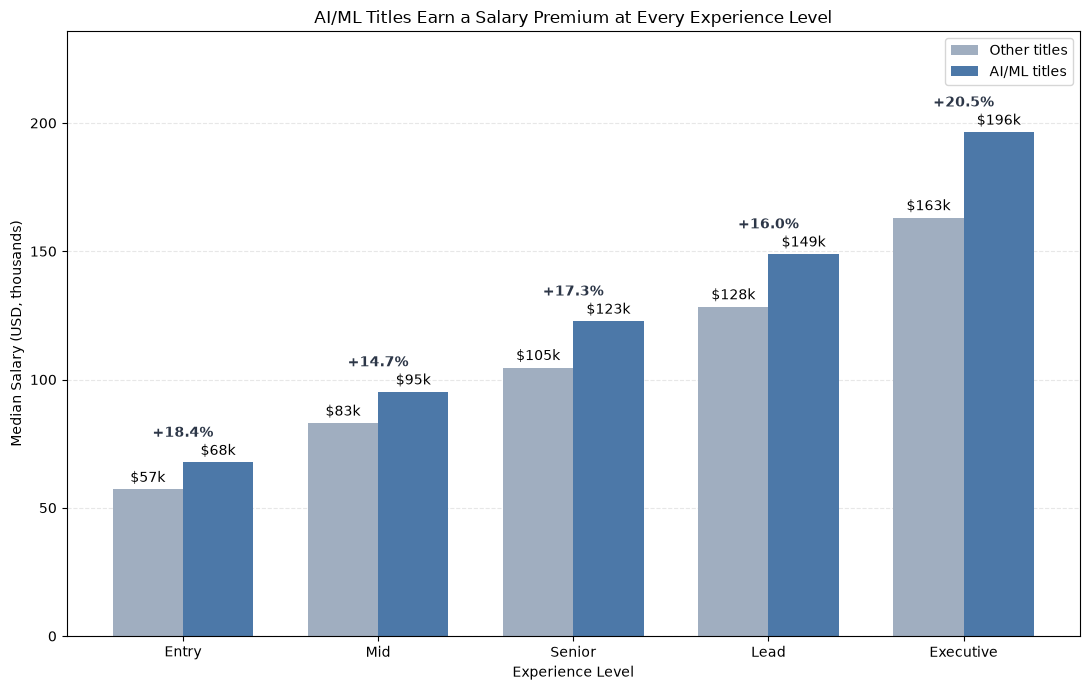

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plot_data = premium_by_experience.reset_index()

x = np.arange(len(plot_data))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(11, 7))

other_bars = ax.bar(
    x - bar_width / 2,
    plot_data["Other titles"] / 1000,
    width=bar_width,
    label="Other titles",
    color="#A0AEC0"
)

ai_ml_bars = ax.bar(
    x + bar_width / 2,
    plot_data["AI/ML titles"] / 1000,
    width=bar_width,
    label="AI/ML titles",
    color="#4C78A8"
)

ax.bar_label(
    other_bars,
    labels=[
        f"${salary / 1000:.0f}k"
        for salary in plot_data["Other titles"]
    ],
    padding=3
)

ax.bar_label(
    ai_ml_bars,
    labels=[
        f"${salary / 1000:.0f}k"
        for salary in plot_data["AI/ML titles"]
    ],
    padding=3
)

# Display the percentage premium above each pair
for position, row in plot_data.iterrows():
    highest_bar = max(
        row["AI/ML titles"],
        row["Other titles"]
    ) / 1000

    ax.text(
        position,
        highest_bar + 10,
        f"+{row['premium_percentage']:.1f}%",
        ha="center",
        fontweight="bold",
        color="#2D3748"
    )

ax.set_xticks(x)
ax.set_xticklabels(plot_data["experience_level"])

ax.set_title(
    "AI/ML Titles Earn a Salary Premium at Every Experience Level"
)
ax.set_xlabel("Experience Level")
ax.set_ylabel("Median Salary (USD, thousands)")
ax.legend()

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)
ax.set_axisbelow(True)

maximum_salary = (
    plot_data[["AI/ML titles", "Other titles"]]
    .to_numpy()
    .max() / 1000
)

ax.set_ylim(0, maximum_salary * 1.2)

fig.tight_layout()

image_folder = Path("images")
image_folder.mkdir(exist_ok=True)

fig.savefig(
    image_folder / "ai_ml_salary_premium.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
remote_mapping = {
    0: "On-site",
    50: "Hybrid",
    100: "Fully remote"
}

work_order = [
    "On-site",
    "Hybrid",
    "Fully remote"
]

df["work_arrangement"] = df["remote_ratio"].map(
    remote_mapping
)

df["work_arrangement"] = pd.Categorical(
    df["work_arrangement"],
    categories=work_order,
    ordered=True
)

In [24]:
remote_summary = (
    df.groupby(
        "work_arrangement",
        observed=True
    )
    .agg(
        number_of_jobs=("job_title", "count"),
        median_weekly_hours=("weekly_hours", "median"),
        average_weekly_hours=("weekly_hours", "mean"),
        median_satisfaction=(
            "job_satisfaction_score",
            "median"
        ),
        average_satisfaction=(
            "job_satisfaction_score",
            "mean"
        )
    )
    .reset_index()
)

remote_summary

,work_arrangement,number_of_jobs,median_weekly_hours,average_weekly_hours,median_satisfaction,average_satisfaction
0,On-site,2112,44.4,44.352888,6.4,6.383996
1,Hybrid,1468,44.5,44.278815,6.8,6.778338
2,Fully remote,1420,44.3,44.403099,7.0,7.037324


In [25]:
overall_correlation = df[
    "weekly_hours"
].corr(
    df["job_satisfaction_score"]
)

print(
    f"Overall correlation: "
    f"{overall_correlation:.3f}"
)

Overall correlation: -0.227


In [26]:
correlation_by_arrangement = (
    df.groupby(
        "work_arrangement",
        observed=True
    )
    .apply(
        lambda group:
        group["weekly_hours"].corr(
            group["job_satisfaction_score"]
        )
    )
)

correlation_by_arrangement

work_arrangement
On-site        -0.251426
Hybrid         -0.225558
Fully remote   -0.211235
dtype: float64

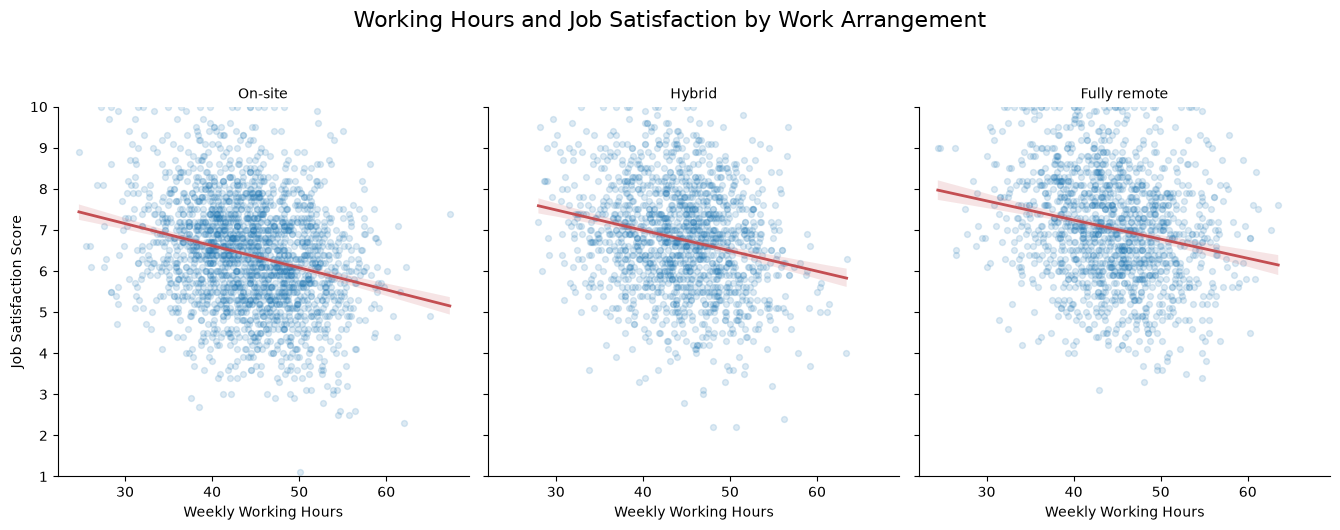

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

chart = sns.lmplot(
    data=df,
    x="weekly_hours",
    y="job_satisfaction_score",
    col="work_arrangement",
    col_order=work_order,
    scatter_kws={
        "alpha": 0.15,
        "s": 18
    },
    line_kws={
        "color": "#C44E52",
        "linewidth": 2
    },
    height=5,
    aspect=0.9
)

chart.set_axis_labels(
    "Weekly Working Hours",
    "Job Satisfaction Score"
)

chart.set_titles("{col_name}")
chart.set(ylim=(1, 10))

chart.figure.suptitle(
    "Working Hours and Job Satisfaction by Work Arrangement",
    fontsize=16,
    y=1.05
)

chart.figure.tight_layout()

image_folder = Path("images")
image_folder.mkdir(exist_ok=True)

chart.figure.savefig(
    image_folder / "remote_hours_satisfaction.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [28]:
education_order = [
    "Self-taught",
    "Bootcamp",
    "Bachelors",
    "Masters",
    "PhD"
]

education_summary = (
    df.groupby(
        "education_level",
        observed=True
    )
    .agg(
        number_of_jobs=("salary_usd", "count"),
        median_salary=("salary_usd", "median"),
        average_salary=("salary_usd", "mean")
    )
    .reindex(education_order)
)

education_summary

,number_of_jobs,median_salary,average_salary
education_level,,,
Self-taught,303,78712.0,88420.326733
Bootcamp,473,82037.0,88048.883721
Bachelors,1903,85833.0,94205.790857
Masters,1786,96034.0,103030.276596
PhD,535,107117.0,114584.777570


In [29]:
education_by_experience = (
    df.pivot_table(
        index="experience_level",
        columns="education_level",
        values="salary_usd",
        aggfunc="median",
        observed=True
    )
    .reindex(
        index=experience_order,
        columns=education_order
    )
)

education_by_experience

education_level,Self-taught,Bootcamp,Bachelors,Masters,PhD
experience_level,,,,,
Entry,57646.0,49401.5,59036.0,61383.0,63263.0
Mid,78368.0,72558.0,82407.5,94276.0,99481.0
Senior,86670.0,98425.0,104982.0,113615.5,129685.0
Lead,122657.0,132978.0,126547.5,143814.0,148933.5
Executive,134124.5,129193.5,161961.0,173172.5,204325.0


In [30]:
education_counts = (
    df.pivot_table(
        index="experience_level",
        columns="education_level",
        values="salary_usd",
        aggfunc="count",
        observed=True
    )
    .reindex(
        index=experience_order,
        columns=education_order
    )
)

education_counts

education_level,Self-taught,Bootcamp,Bachelors,Masters,PhD
experience_level,,,,,
Entry,63,98,381,364,79
Mid,93,169,622,551,178
Senior,97,125,569,552,177
Lead,28,63,252,235,78
Executive,22,18,79,84,23


In [31]:
certification_summary = (
    df.groupby("certifications_count")
      .agg(
          number_of_jobs=("salary_usd", "count"),
          median_salary=("salary_usd", "median"),
          average_salary=("salary_usd", "mean")
      )
      .reset_index()
)

certification_summary

,certifications_count,number_of_jobs,median_salary,average_salary
0,0,797,83960.0,91065.816813
1,1,1491,88836.0,94551.586854
2,2,1352,89203.0,99097.881657
3,3,791,95506.0,104284.428571
4,4,379,103914.0,109284.319261
5,5,132,113081.0,114586.916667
6,6,49,106794.0,111913.428571
7,7,8,100310.0,96190.875000
8,8,1,204325.0,204325.000000


In [32]:
certification_correlation = df[
    "certifications_count"
].corr(
    df["salary_usd"],
    method="spearman"
)

print(
    f"Overall Spearman correlation: "
    f"{certification_correlation:.3f}"
)

Overall Spearman correlation: 0.097


In [33]:
certification_correlation_by_experience = (
    df.groupby(
        "experience_level",
        observed=True
    )
    .apply(
        lambda group: group[
            "certifications_count"
        ].corr(
            group["salary_usd"],
            method="spearman"
        ),
        include_groups=False
    )
    .reindex(experience_order)
)

certification_correlation_by_experience

experience_level
Entry       -0.023833
Mid         -0.019537
Senior       0.002187
Lead         0.030946
Executive   -0.024754
dtype: float64

In [34]:
df["management_status"] = df[
    "manages_people"
].map({
    False: "Does not manage people",
    True: "Manages people"
})

In [35]:
management_summary = (
    df.groupby("management_status")
      .agg(
          number_of_jobs=("salary_usd", "count"),
          median_salary=("salary_usd", "median"),
          average_salary=("salary_usd", "mean")
      )
)

management_summary

,number_of_jobs,median_salary,average_salary
management_status,,,
Does not manage people,3860,84274.5,89042.046891
Manages people,1140,123953.5,130986.605263


In [36]:
management_by_experience = (
    df.pivot_table(
        index="experience_level",
        columns="management_status",
        values="salary_usd",
        aggfunc="median",
        observed=True
    )
    .reindex(experience_order)
)

management_by_experience

management_status,Does not manage people,Manages people
experience_level,,
Entry,60268.0,55384.0
Mid,86040.0,80520.5
Senior,108843.0,107698.5
Lead,NaN,131778.0
Executive,NaN,169078.0


In [37]:
management_by_experience["premium_usd"] = (
    management_by_experience["Manages people"]
    - management_by_experience[
        "Does not manage people"
    ]
)

management_by_experience["premium_percentage"] = (
    management_by_experience["premium_usd"]
    / management_by_experience[
        "Does not manage people"
    ]
) * 100

management_by_experience

management_status,Does not manage people,Manages people,premium_usd,premium_percentage
experience_level,,,,
Entry,60268.0,55384.0,-4884.0,-8.103803
Mid,86040.0,80520.5,-5519.5,-6.415040
Senior,108843.0,107698.5,-1144.5,-1.051515
Lead,NaN,131778.0,NaN,NaN
Executive,NaN,169078.0,NaN,NaN


In [38]:
management_counts = (
    df.pivot_table(
        index="experience_level",
        columns="management_status",
        values="salary_usd",
        aggfunc="count",
        observed=True
    )
    .reindex(experience_order)
)

management_counts

management_status,Does not manage people,Manages people
experience_level,,
Entry,921.0,64.0
Mid,1511.0,102.0
Senior,1428.0,92.0
Lead,NaN,656.0
Executive,NaN,226.0


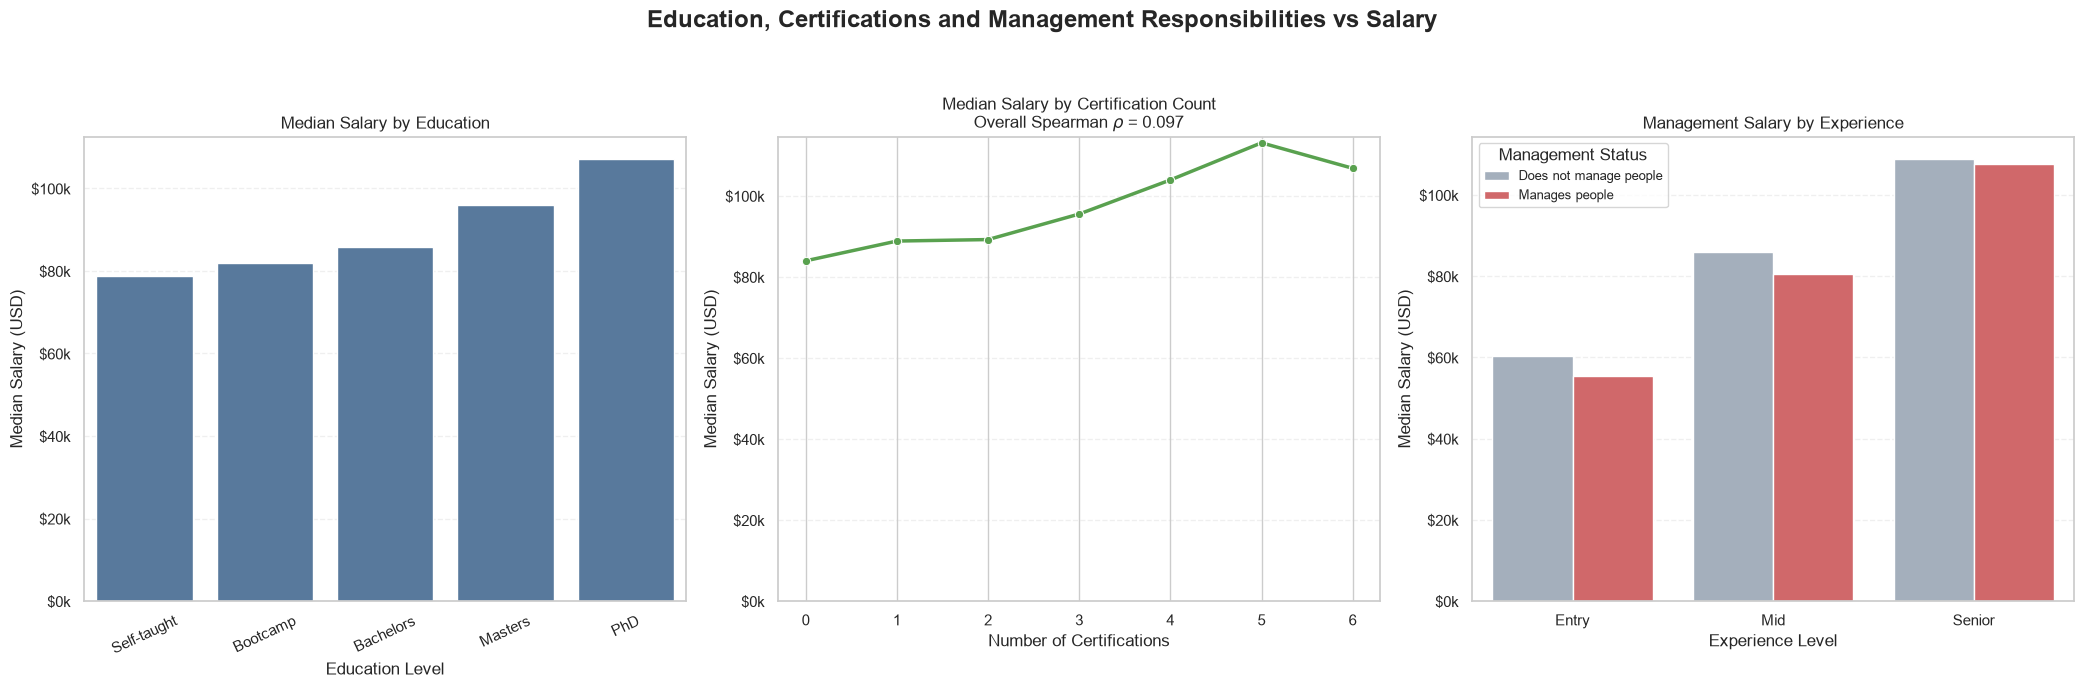

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from pathlib import Path

sns.set_theme(style="whitegrid")

# Prepare education data
education_plot = education_summary.reset_index()

# Exclude certification groups with fewer than 20 observations
certification_plot = certification_summary[
    certification_summary["number_of_jobs"] >= 20
].copy()

# Only retain experience levels where both management groups exist
management_plot = (
    management_by_experience
    .loc[
        ["Entry", "Mid", "Senior"],
        ["Does not manage people", "Manages people"]
    ]
    .reset_index()
    .melt(
        id_vars="experience_level",
        var_name="management_status",
        value_name="median_salary"
    )
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 7)
)

# 1. Education
sns.barplot(
    data=education_plot,
    x="education_level",
    y="median_salary",
    order=education_order,
    color="#4C78A8",
    ax=axes[0]
)

axes[0].set_title("Median Salary by Education")
axes[0].set_xlabel("Education Level")
axes[0].set_ylabel("Median Salary (USD)")
axes[0].tick_params(axis="x", rotation=25)

# 2. Certifications
sns.lineplot(
    data=certification_plot,
    x="certifications_count",
    y="median_salary",
    marker="o",
    linewidth=2.5,
    color="#59A14F",
    ax=axes[1]
)

axes[1].set_title(
    "Median Salary by Certification Count\n"
    r"Overall Spearman $\rho$ = 0.097"
)
axes[1].set_xlabel("Number of Certifications")
axes[1].set_ylabel("Median Salary (USD)")
axes[1].set_xticks(
    certification_plot["certifications_count"]
)

# 3. Management
sns.barplot(
    data=management_plot,
    x="experience_level",
    y="median_salary",
    hue="management_status",
    palette=["#A0AEC0", "#E15759"],
    ax=axes[2]
)

axes[2].set_title(
    "Management Salary by Experience"
)
axes[2].set_xlabel("Experience Level")
axes[2].set_ylabel("Median Salary (USD)")
axes[2].legend(
    title="Management Status",
    fontsize=9
)

# Format salary axes
currency_formatter = FuncFormatter(
    lambda value, position: f"${value / 1000:.0f}k"
)

for axis in axes:
    axis.yaxis.set_major_formatter(currency_formatter)
    axis.set_ylim(bottom=0)
    axis.grid(axis="y", linestyle="--", alpha=0.3)
    axis.set_axisbelow(True)

fig.suptitle(
    "Education, Certifications and Management Responsibilities vs Salary",
    fontsize=17,
    fontweight="bold"
)

fig.tight_layout(rect=[0, 0, 1, 0.94])

image_folder = Path("images")
image_folder.mkdir(exist_ok=True)

fig.savefig(
    image_folder / "education_certification_management_salary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()